## Mapas por Região e Estado de Acidentes

A análise geográfica de acidentes no Brasil permite identificar padrões e concentrações de ocorrências em todo o território nacional. Por meio de mapas organizados por região e estado, gestores públicos conseguem visualizar onde os riscos são mais elevados e direcionar ações de forma mais eficiente.

Os dados utilizados nesses mapas são fornecidos principalmente pela **Polícia Rodoviária Federal (PRF)** e estão disponiveis em [gov.br/prf](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf). Permiti identificar pontos críticos e orientar investimentos em sinalização, fiscalização e infraestrutura viária.

In [70]:
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import geobr as geobr
import folium

dados = pd.read_csv('acidentes2026_todas_causas_tipos.csv', encoding='latin-1', sep=';', decimal=',')
display(dados)

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_principal,...,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop
0,742884,1663693.0,2026-01-01,quinta-feira,00:05:00,SC,101.0,145.0,ITAPEMA,Sim,...,Masculino,0.0,1.0,0.0,0.0,-27.084768,-48.606356,SPRF-SC,DEL04-SC,UOP03-DEL04-SC
1,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,639.3,TIJUCAS DO SUL,Não,...,Masculino,1.0,0.0,0.0,0.0,-25.783081,-49.120916,SPRF-PR,DEL01-PR,UOP04-DEL01-PR
2,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,639.3,TIJUCAS DO SUL,Não,...,Masculino,1.0,0.0,0.0,0.0,-25.783081,-49.120916,SPRF-PR,DEL01-PR,UOP04-DEL01-PR
3,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,639.3,TIJUCAS DO SUL,Sim,...,Masculino,1.0,0.0,0.0,0.0,-25.783081,-49.120916,SPRF-PR,DEL01-PR,UOP04-DEL01-PR
4,742888,1663874.0,2026-01-01,quinta-feira,00:05:00,MG,262.0,108.0,SANTO ANTONIO DO GRAMA,Sim,...,Masculino,1.0,0.0,0.0,0.0,-20.270390,-42.570276,SPRF-MG,DEL03-MG,UOP03-DEL03-MG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101119,759804,1706908.0,2026-02-27,sexta-feira,20:18:00,MG,381.0,935.5,EXTREMA,Não,...,Masculino,1.0,0.0,0.0,0.0,-22.809040,-46.280025,SPRF-MG,DEL16-MG,UOP03-DEL16-MG
101120,759804,1706907.0,2026-02-27,sexta-feira,20:18:00,MG,381.0,935.5,EXTREMA,Não,...,Masculino,1.0,0.0,0.0,0.0,-22.809040,-46.280025,SPRF-MG,DEL16-MG,UOP03-DEL16-MG
101121,759835,1706993.0,2026-01-16,sexta-feira,20:30:00,RJ,101.0,43.0,CAMPOS DOS GOYTACAZES,Sim,...,Masculino,1.0,0.0,0.0,0.0,-21.597675,-41.316907,SPRF-RJ,DEL08-RJ,UOP01-DEL08-RJ
101122,759835,1706992.0,2026-01-16,sexta-feira,20:30:00,RJ,101.0,43.0,CAMPOS DOS GOYTACAZES,Sim,...,Masculino,1.0,0.0,0.0,0.0,-21.597675,-41.316907,SPRF-RJ,DEL08-RJ,UOP01-DEL08-RJ


## Tratamento e limpeza dos dados

* Compreender as principais medidas descritivas, como **média**, **mediana** e medidas de **dispersão** (desvio padrão, variância, amplitude), a fim de identificar o comportamento geral dos dados e possíveis outliers.

* Realizar o tratamento de valores ausentes (*missing values*), incluindo:

  * Remoção de observações com dados faltantes, quando apropriado;
  * Avaliação de estratégias de imputação, caso a exclusão comprometa a análise;
  * Correção ou exclusão de registros inconsistentes, como **IDs inválidos ou não encontrados**.

* Padronizar e converter as unidades das variáveis para formatos consistentes, garantindo a comparabilidade dos dados e evitando erros analíticos decorrentes de escalas distintas.

* Verificar e corrigir inconsistências, como:

  * Valores fora do domínio esperado;
  * Duplicidades;
  * Erros de digitação ou formatação.


In [69]:
dados = dados.drop(columns=['id',  'pesid', 'delegacia', 'uop',  'latitude', 'longitude', 'ano_fabricacao_veiculo', 'marca', 'id_veiculo', 'regional', 'km'])
dados = dados.astype({
    'dia_semana':     'category',
    'uf':             'category',
    'tipo_acidente':  'category',
    'causa_acidente': 'category',
    'estado_fisico':  'category',
    'sexo':           'category',
    'br':             'category',
    'municipio':      'category',
    'ordem_tipo_acidente': 'category',
    'uso_solo':       'category',
    'mortos':         'bool',      # houve morto? True/False
    'ilesos':         'bool',
    'feridos_leves':  'bool',
    'feridos_graves': 'bool',
})
dados.dropna()
dados['horario'] = pd.to_datetime(dados['horario'], format='%H:%M:%S', errors='coerce').dt.hour
tabela_resumo = dados.describe(include='all');
display(tabela_resumo)

,data_inversa,dia_semana,horario,uf,br,municipio,causa_principal,causa_acidente,ordem_tipo_acidente,tipo_acidente,...,uso_solo,tipo_veiculo,tipo_envolvido,estado_fisico,idade,sexo,ilesos,feridos_leves,feridos_graves,mortos
count,101124,101124,101124.000000,101124,100915.0,101124,101124,101124,101124.0,101124,...,101124,98288,91485,91485,84338.000000,91485,101124,101124,101124,101124
unique,59,7,NaN,27,104.0,1447,2,68,14.0,17,...,2,21,5,5,NaN,4,2,2,2,2
top,2026-02-22,sábado,NaN,MG,116.0,BRASILIA,Sim,Reação tardia ou ineficiente do condutor,1.0,Tombamento,...,Não,Automóvel,Condutor,Ileso,NaN,Masculino,False,False,False,False
freq,2875,16569,NaN,12419,12920.0,1447,57571,14434,51158.0,14513,...,65246,32381,56757,37109,NaN,61298,54376,58555,79970,86829
mean,NaN,NaN,12.698914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39.661398,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.041576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,25.647078,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,38.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN


A base de dados analisada contém 101.124 registros, contemplando variáveis de natureza temporal, espacial e características dos acidentes e dos indivíduos envolvidos.

No que se refere à dimensão temporal, observa-se que a variável **data da ocorrência (`data_inversa`)** apresenta 59 datas distintas, indicando concentração dos registros em um intervalo relativamente curto. A data mais frequente foi 22 de fevereiro de 2026, com 2.875 ocorrências. A variável **dia da semana (`dia_semana`)** mostra distribuição ao longo dos sete dias, com maior incidência no sábado (16.569 registros). A variável **horário do acidente (`horario`)** apresenta média de 12,7 horas, mediana de 13 horas e desvio padrão de 6,04 horas, evidenciando predominância de ocorrências no período diurno, especialmente entre 8 e 18 horas.

No aspecto espacial, a variável **unidade federativa (`uf`)** abrange as 27 unidades do país, com destaque para Minas Gerais, que concentra 12.419 registros. A variável **município da ocorrência (`municipio`)** apresenta elevada diversidade, com 1.447 municípios distintos, sendo Brasília o mais frequente. As variáveis **rodovia federal (`br`)** e **quilômetro da rodovia (`km`)** indicam a localização dos eventos, com 104 rodovias distintas e predominância da BR-116 (12.920 ocorrências).

Em relação às características dos acidentes, a variável **indicador de causa principal (`causa_principal`)** possui duas categorias, com predominância da categoria "Sim" (57.571 registros). A variável **causa do acidente (`causa_acidente`)** apresenta 68 categorias, sendo a mais frequente "Reação tardia ou ineficiente do condutor" (14.434 ocorrências), o que sugere forte influência de fatores humanos. A variável **ordem do tipo de acidente (`ordem_tipo_acidente`)** apresenta 14 categorias, com predominância da categoria 1 (51.158 registros), indicando concentração em tipos específicos de ocorrência.

No que diz respeito aos veículos, a variável **tipo de veículo (`tipo_veiculo`)** apresenta 21 categorias, sendo "Automóvel" a mais frequente (32.381 registros). A variável **uso do solo (`uso_solo`)** não apresenta 2 categorias diz respeito a características do local do acidente:, indicando a predominância da Zona Rural com cerca de 65246 ocorrências.

Quanto aos indivíduos envolvidos, a variável **tipo de envolvido (`tipo_envolvido`)** indica predominância de condutores (56.757 registros). A variável **estado físico do envolvido (`estado_fisico`)** mostra que a maior parte dos indivíduos encontra-se ilesa (37.109 registros). A variável **idade (`idade`)** apresenta média de 39,66 anos, mediana de 38 anos com especialmente entre 50 e 28 anos de idade.

A variável **sexo do envolvido (`sexo`)** apresenta predominância do sexo masculino (61.298 registros). As variáveis indicadoras **ilesos (`ilesos`)**, **feridos leves (`feridos_leves`)**, **feridos graves (`feridos_graves`)** e **óbitos (`mortos`)** apontam predominância de ocorrências sem vítimas fatais, embora haja registros relevantes de feridos e mortes.

De modo geral, os resultados indicam concentração temporal nos finais de semana, predominância de ocorrências no período diurno, forte influência de fatores humanos nas causas dos acidentes e concentração espacial em determinadas unidades federativas e rodovias.

In [75]:
contagens = (dados
    .groupby('uf')['mortos']
    .sum()
    .reset_index()
    .rename(columns={'mortos': 'Contagem_mortos'})
    .sort_values('Contagem_mortos', ascending=False)
)
print("TOP 10 estados com mais mortos:")
display(contagens.head(10))
print("Total de mortos em acidentes de trânsito no Brasil (2026):")
sum(contagens['Contagem_mortos'])

TOP 10 estados com mais mortos:


,uf,Contagem_mortos
10,MG,573.0
17,PR,570.0
23,SC,308.0
8,GO,303.0
22,RS,266.0
12,MT,261.0
26,TO,237.0
15,PE,221.0
16,PI,216.0
20,RO,215.0


Total de mortos em acidentes de trânsito no Brasil (2026):


4656.0

In [7]:
# Baixa o GeoDataFrame com os estados do Brasil e DF
br_uf = geobr.read_state()  
br_uf_d = br_uf.merge(contagens, 
                     left_on='abbrev_state',    
                     right_on='uf', 
                     how='left')
br_uf_d = br_uf_d[["geometry", "Contagem_mortos"]]  

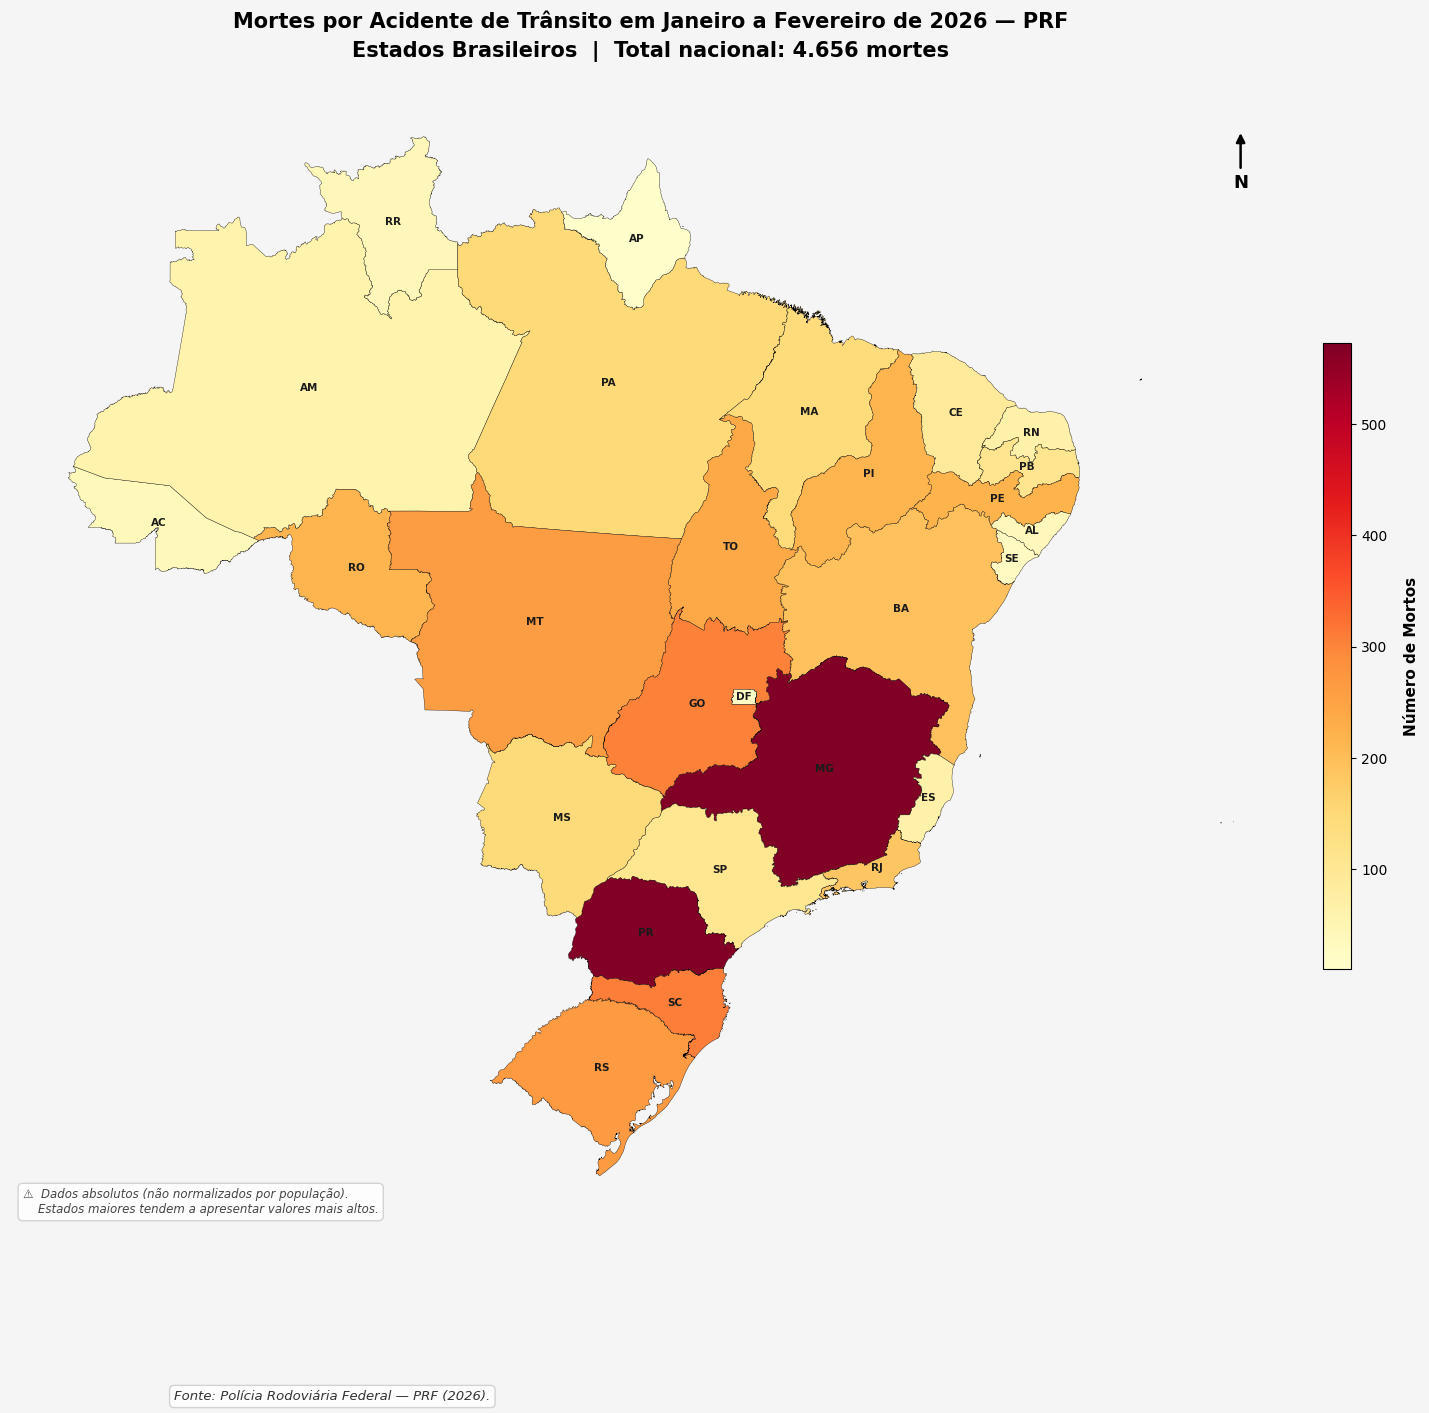

In [77]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch

# =============================================================================
# MAPA COROPLÉTICO — Mortes por Acidente de Trânsito (PRF, Janeiro 2026)
# Versão melhorada: siglas dos estados, título na colorbar, paleta com mais
# contraste, nota de normalização, seta de norte e rodapé no lugar correto.
# =============================================================================

# --- 1. FIGURA BASE -----------------------------------------------------------
# Cria figura 16x16 polegadas (quadrado ideal para o Brasil)
f, ax = plt.subplots()
f.set_size_inches(16, 16)

# Cor de fundo levemente acinzentada ← Dá profundidade ao mapa, evita branco cru
f.patch.set_facecolor("#F5F5F5")
ax.set_facecolor("#E8EEF4")          # Oceano / área fora do Brasil

# --- 2. MAPA COROPLÉTICO ------------------------------------------------------
# Plota estados coloridos pela contagem de mortes
# MELHORIA: paleta "YlOrRd" no lugar de "Reds" ← Diferencia melhor os valores
# intermediários (amarelo → laranja → vermelho), evitando que estados médios
# fiquem "invisíveis" na escala de cores
br_uf_d.plot(
    ax=ax,
    column="Contagem_mortos",        # Coluna numérica para colorir estados
    cmap="YlOrRd",                   # ← MELHORADO: mais contraste entre faixas
    edgecolor="black",               # Bordas pretas entre estados
    linewidth=0.25,                  # Espessura fina — não compete com o dado
    legend=False,                    # Legenda manual (colorbar customizada abaixo)
    missing_kwds={
        'color': 'lightgrey',        # Cinza para estados sem registro de mortes
        'label': 'Sem dados'         # Rótulo na legenda (boa prática cartográfica)
    }
)

# --- 3. SIGLAS DOS ESTADOS ----------------------------------------------------
# MELHORIA PRINCIPAL: sem isso o leitor precisa conhecer a geografia de cor
# Itera por cada estado e plota a sigla no centróide do polígono
for idx, row in br_uf_d.iterrows():
    # centroid.x / centroid.y = coordenadas geográficas do centro de cada estado
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    # Pega a sigla da coluna correta do seu GeoDataFrame ← ajuste se necessário
    sigla = row.get("SIGLA_UF") or row.get("abbrev_state") or row.get("UF", "")

    ax.annotate(
        text=sigla,
        xy=(x, y),                   # Posição: centro do estado
        ha='center',                 # Alinhamento horizontal centralizado
        va='center',                 # Alinhamento vertical centralizado
        fontsize=7.5,                # Fonte pequena para não poluir o mapa
        fontweight='bold',
        color='#1a1a1a',             # Quase preto ← legível sobre qualquer cor
        zorder=5                     # Garante que fica acima dos polígonos
    )

# --- 4. TÍTULO PRINCIPAL E SUBTÍTULO ------------------------------------------
# MELHORIA: subtítulo com total nacional dá dimensão imediata ao problema
total_mortes = int(br_uf_d["Contagem_mortos"].sum())  # Total nacional calculado

ax.set_title(
    "Mortes por Acidente de Trânsito em Janeiro a Fevereiro de 2026 — PRF\n"
    f"Estados Brasileiros  |  Total nacional: {total_mortes:,} mortes".replace(",", "."),
    fontsize=15,
    fontweight='bold',
    pad=20,
    linespacing=1.6                  # Espaço entre linha do título e subtítulo
)

# Remove eixos X/Y ← Estilo cartográfico limpo (coordenadas poluem o visual)
ax.set_axis_off()

# --- 5. COLORBAR CUSTOMIZADA --------------------------------------------------
# Barra de cores lateral com rótulo e formatação em milhares

cbar = plt.colorbar(
    ax.collections[0],               # Mappable: primeiro conjunto de polígonos
    ax=ax,
    shrink=0.45,                     # 45% da altura da figura
    pad=0.02,                        # Pequeno espaço entre mapa e colorbar
    aspect=22                        # Proporção retangular da barra
)

# MELHORIA: título da colorbar ← sem isso o leitor não sabe o que a cor mede
cbar.set_label(
    "Número de Mortos",
    fontsize=11,
    fontweight='bold',
    labelpad=12                      # Espaço entre a barra e o texto do rótulo
)

# Formata ticks: 573 → 0.6K (mais legível que número bruto)
cbar.formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x/1000:.1f}K' if x >= 1000 else str(int(x))
)
cbar.ax.tick_params(labelsize=10)   # ← MELHORIA: ticks maiores, mais legíveis
cbar.update_ticks()                  # Aplica a formatação customizada

# --- 6. SETA DE NORTE ---------------------------------------------------------
# MELHORIA: orientação geográfica — padrão em mapas profissionais
# Posição em coordenadas de figura (0–1), canto superior direito do mapa
ax.annotate(
    "N",                             # Letra N (Norte)
    xy=(0.96, 0.96),                 # Ponta da seta (destino)
    xytext=(0.96, 0.91),             # Base da seta (origem)
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    fontsize=13,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle="-|>",            # Seta com cabeça preenchida
        color='black',
        lw=1.8
    )
)

# --- 7. NOTA METODOLÓGICA -----------------------------------------------------
# MELHORIA CRÍTICA: dados absolutos favorecem estados populosos (SP, MG, RJ)
# Uma nota curta evita interpretação errada pelo leitor
ax.text(
    0.01, 0.01,                      # Canto inferior esquerdo do eixo
    "⚠  Dados absolutos (não normalizados por população).\n"
    "    Estados maiores tendem a apresentar valores mais altos.",
    transform=ax.transAxes,          # Coordenadas relativas ao eixo (0–1)
    fontsize=8.5,
    color='#444444',
    style='italic',
    verticalalignment='bottom',
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.85,
        edgecolor='#cccccc'
    )
)

# --- 8. RODAPÉ COM FONTE DOS DADOS --------------------------------------------
# MELHORIA: posição corrigida para y≈0.02 ← antes estava em y=0.20 (meio do mapa)
f.text(
    0.12,                            # X: 12% da largura (margem esquerda)
    0.03,                            # Y: 3% da altura ← rodapé real da figura
    "Fonte: Polícia Rodoviária Federal — PRF (2026).",
    fontsize=9.5,
    style='italic',
    color='#333333',
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85,
        edgecolor='#cccccc'
    )
)

# --- 9. LAYOUT FINAL ----------------------------------------------------------
plt.tight_layout(pad=2)             # Espaçamento automático entre elementos
plt.subplots_adjust(bottom=0.06, top=0.93)  # Margens para título e rodapé

# --- 10. EXPORTAÇÃO (alta resolução) ------------------------------------------
# Descomente para salvar relatório em 300 DPI (padrão gráfico profissional)
# f.savefig(
#     'acidentes_prf_janeiro_2026_v2.png',
#     dpi=300,
#     bbox_inches='tight',
#     facecolor=f.get_facecolor(),   # Preserva cor de fundo definida acima
#     edgecolor='none'
# )

plt.show()

O mapa evidencia a distribuição espacial das mortes por acidentes de trânsito no Brasil, apresentando padrão semelhante ao observado para os feridos graves. Há forte concentração de óbitos nas regiões Sudeste e Sul, com destaque para Minas Gerais e Paraná, que apresentam os maiores valores absolutos.

As regiões Norte e parte do Nordeste registram menores números de mortes, enquanto o Centro-Oeste apresenta níveis intermediários. Esse padrão reforça a influência de fatores como volume de tráfego, densidade populacional e extensão da malha rodoviária, mais intensos nas regiões mais desenvolvidas.

De forma geral, a distribuição sugere que o número de óbitos está mais associado à exposição ao tráfego do que necessariamente ao risco individual. Assim, estados com maior circulação de veículos tendem a concentrar mais mortes.

Em síntese, observa-se uma clara concentração regional dos óbitos nas áreas com maior fluxo rodoviário, indicando a necessidade de análises complementares baseadas em taxas para avaliar de forma mais precisa o risco relativo entre os estados.


In [78]:
contagens = (dados
    .groupby('uf')['feridos_graves']
    .sum()
    .reset_index()
    .rename(columns={'feridos_graves': 'Contagem_feridos_graves'})
    .sort_values('Contagem_feridos_graves', ascending=False)
)
print("TOP 10 estados com mais feridos graves:")
display(contagens.head(10))
print("Total de feridos graves em acidentes de trânsito no Brasil (2026):")
sum(contagens['Contagem_feridos_graves'])

TOP 10 estados com mais feridos graves:


,uf,Contagem_feridos_graves
23,SC,1312.0
10,MG,1286.0
17,PR,1224.0
4,BA,943.0
8,GO,693.0
15,PE,604.0
14,PB,561.0
16,PI,535.0
12,MT,499.0
22,RS,445.0


Total de feridos graves em acidentes de trânsito no Brasil (2026):


11515.0

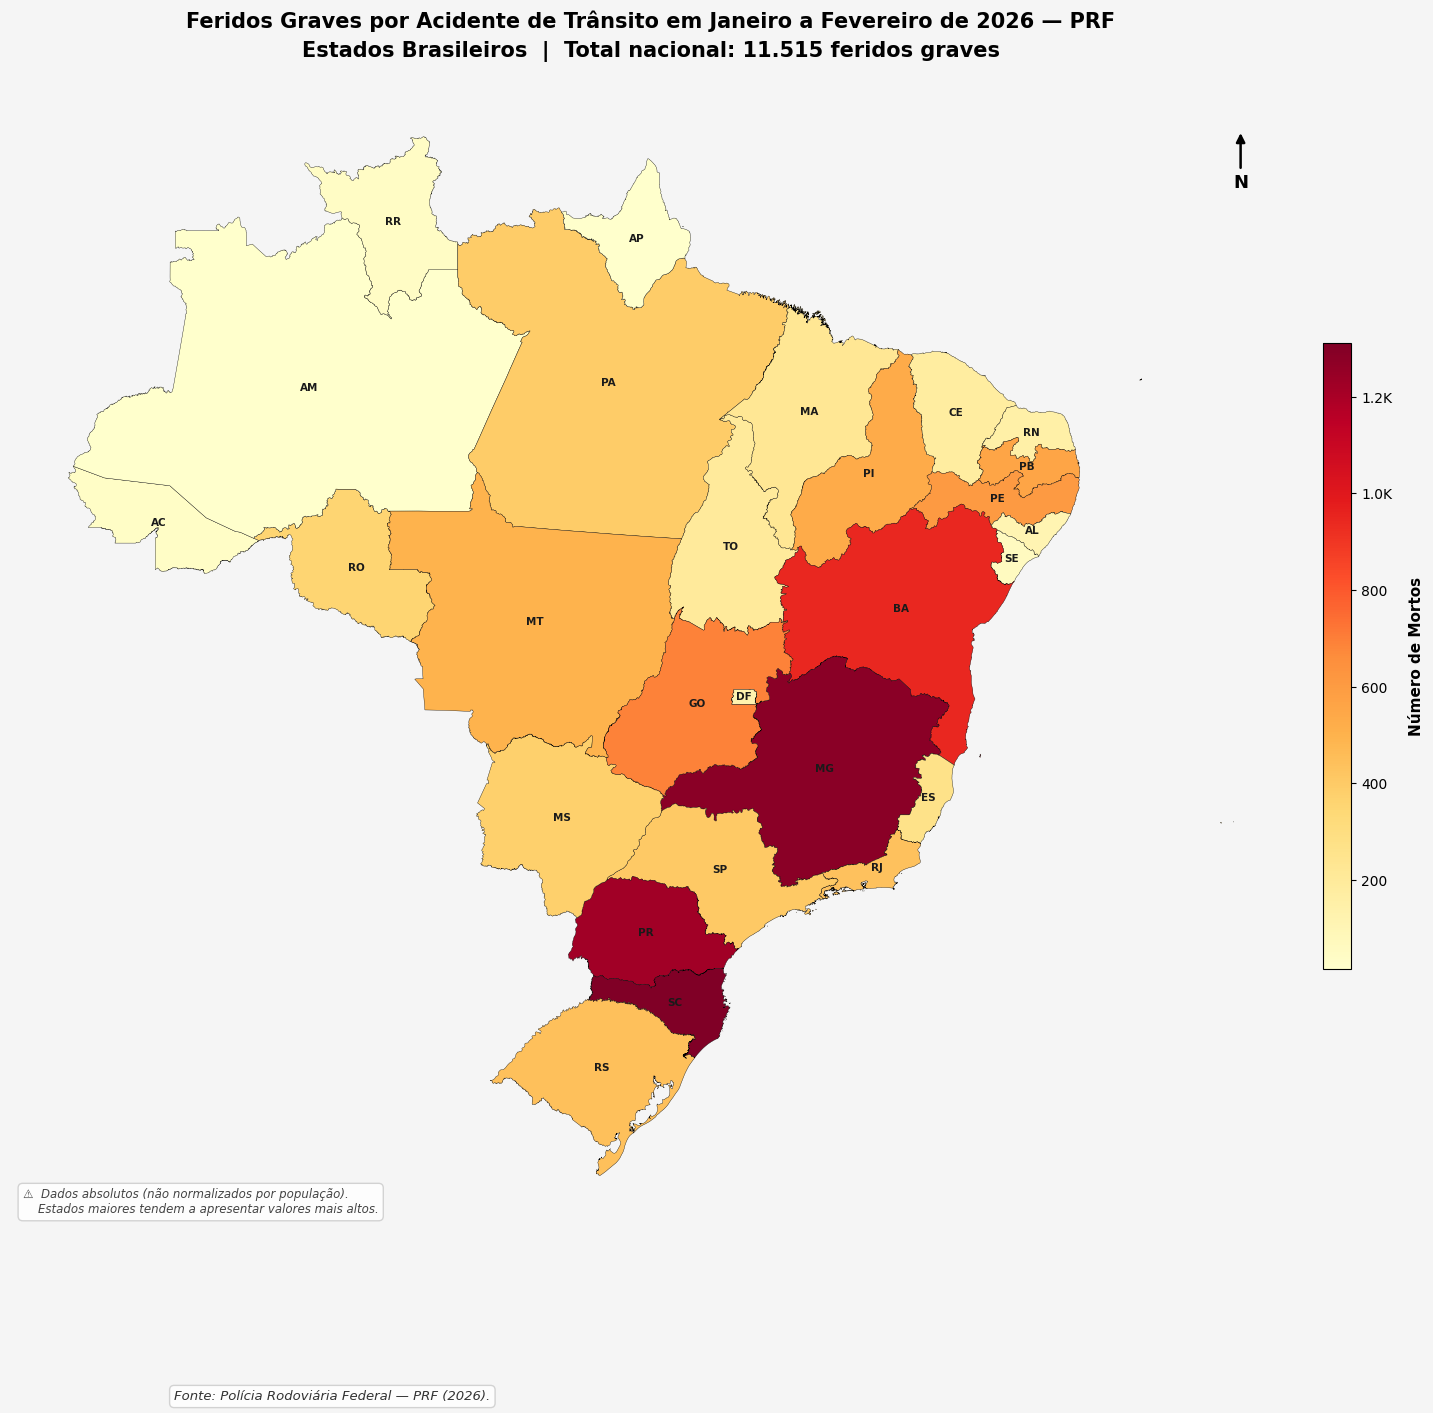

In [85]:
br_uf_d = br_uf.merge(contagens, 
                     left_on='abbrev_state',    
                     right_on='uf', 
                     how='left')
br_uf_d = br_uf_d[["geometry", "Contagem_feridos_graves", "abbrev_state"]]

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

f, ax = plt.subplots()
f.set_size_inches(16, 16)

f.patch.set_facecolor("#F5F5F5")
ax.set_facecolor("#E8EEF4")

br_uf_d.plot(
    ax=ax,
    column="Contagem_feridos_graves",
    cmap="YlOrRd",  
    edgecolor="black",
    linewidth=0.25,
    legend=False,
    missing_kwds={
        'color': 'lightgrey',
        'label': 'Sem dados'
    }
)

for idx, row in br_uf_d.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    sigla = row.get("SIGLA_UF") or row.get("abbrev_state") or row.get("UF", "")
    
    ax.annotate(
        text=sigla,
        xy=(x, y),
        ha='center',
        va='center',
        fontsize=7.5,
        fontweight='bold',
        color='#1a1a1a',
        zorder=5
    )

total_feridos_graves = int(br_uf_d["Contagem_feridos_graves"].sum())

ax.set_title(
    "Feridos Graves por Acidente de Trânsito em Janeiro a Fevereiro de 2026 — PRF\n"
    f"Estados Brasileiros  |  Total nacional: {total_feridos_graves:,} feridos graves".replace(",", "."),
    fontsize=15,
    fontweight='bold',
    pad=20,
    linespacing=1.6
)

ax.set_axis_off()

cbar = plt.colorbar(
    ax.collections[0],
    ax=ax,
    shrink=0.45,
    pad=0.02,
    aspect=22
)

cbar.set_label(
    "Número de Mortos",
    fontsize=11,
    fontweight='bold',
    labelpad=12
)

cbar.formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x/1000:.1f}K' if x >= 1000 else str(int(x))
)
cbar.ax.tick_params(labelsize=10)
cbar.update_ticks()

ax.annotate(
    "N",
    xy=(0.96, 0.96),
    xytext=(0.96, 0.91),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    fontsize=13,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle="-|>",
        color='black',
        lw=1.8
    )
)

ax.text(
    0.01, 0.01,
    "⚠  Dados absolutos (não normalizados por população).\n"
    "    Estados maiores tendem a apresentar valores mais altos.",
    transform=ax.transAxes,
    fontsize=8.5,
    color='#444444',
    style='italic',
    verticalalignment='bottom',
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.85,
        edgecolor='#cccccc'
    )
)

f.text(
    0.12,
    0.03,
    "Fonte: Polícia Rodoviária Federal — PRF (2026).",
    fontsize=9.5,
    style='italic',
    color='#333333',
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85,
        edgecolor='#cccccc'
    )
)

plt.tight_layout(pad=2)
plt.subplots_adjust(bottom=0.06, top=0.93)

plt.show()

O mapa apresenta a distribuição espacial do número de feridos graves em acidentes de trânsito no Brasil, evidenciando forte concentração nas regiões Sudeste e Sul. Destaca-se especialmente o estado de Minas Gerais, com o maior volume absoluto, seguido por estados como São Paulo, Paraná e Rio Grande do Sul.

Nas regiões Norte e parte do Nordeste, observa-se menor intensidade, indicando menor número absoluto de ocorrências. Já o Centro-Oeste apresenta valores intermediários, sem grandes destaques em relação ao restante do país.

Esse padrão sugere que o número de feridos graves está fortemente associado a fatores como maior densidade populacional, volume de tráfego e extensão da malha rodoviária, mais intensos nas regiões mais desenvolvidas do país. Portanto, não necessariamente indica maior risco relativo, mas sim maior exposição ao tráfego.

Em síntese, há uma clara concentração espacial dos casos nas regiões com maior fluxo de veículos, reforçando a necessidade de análises complementares que considerem taxas (por população ou frota) para uma avaliação mais precisa do risco.


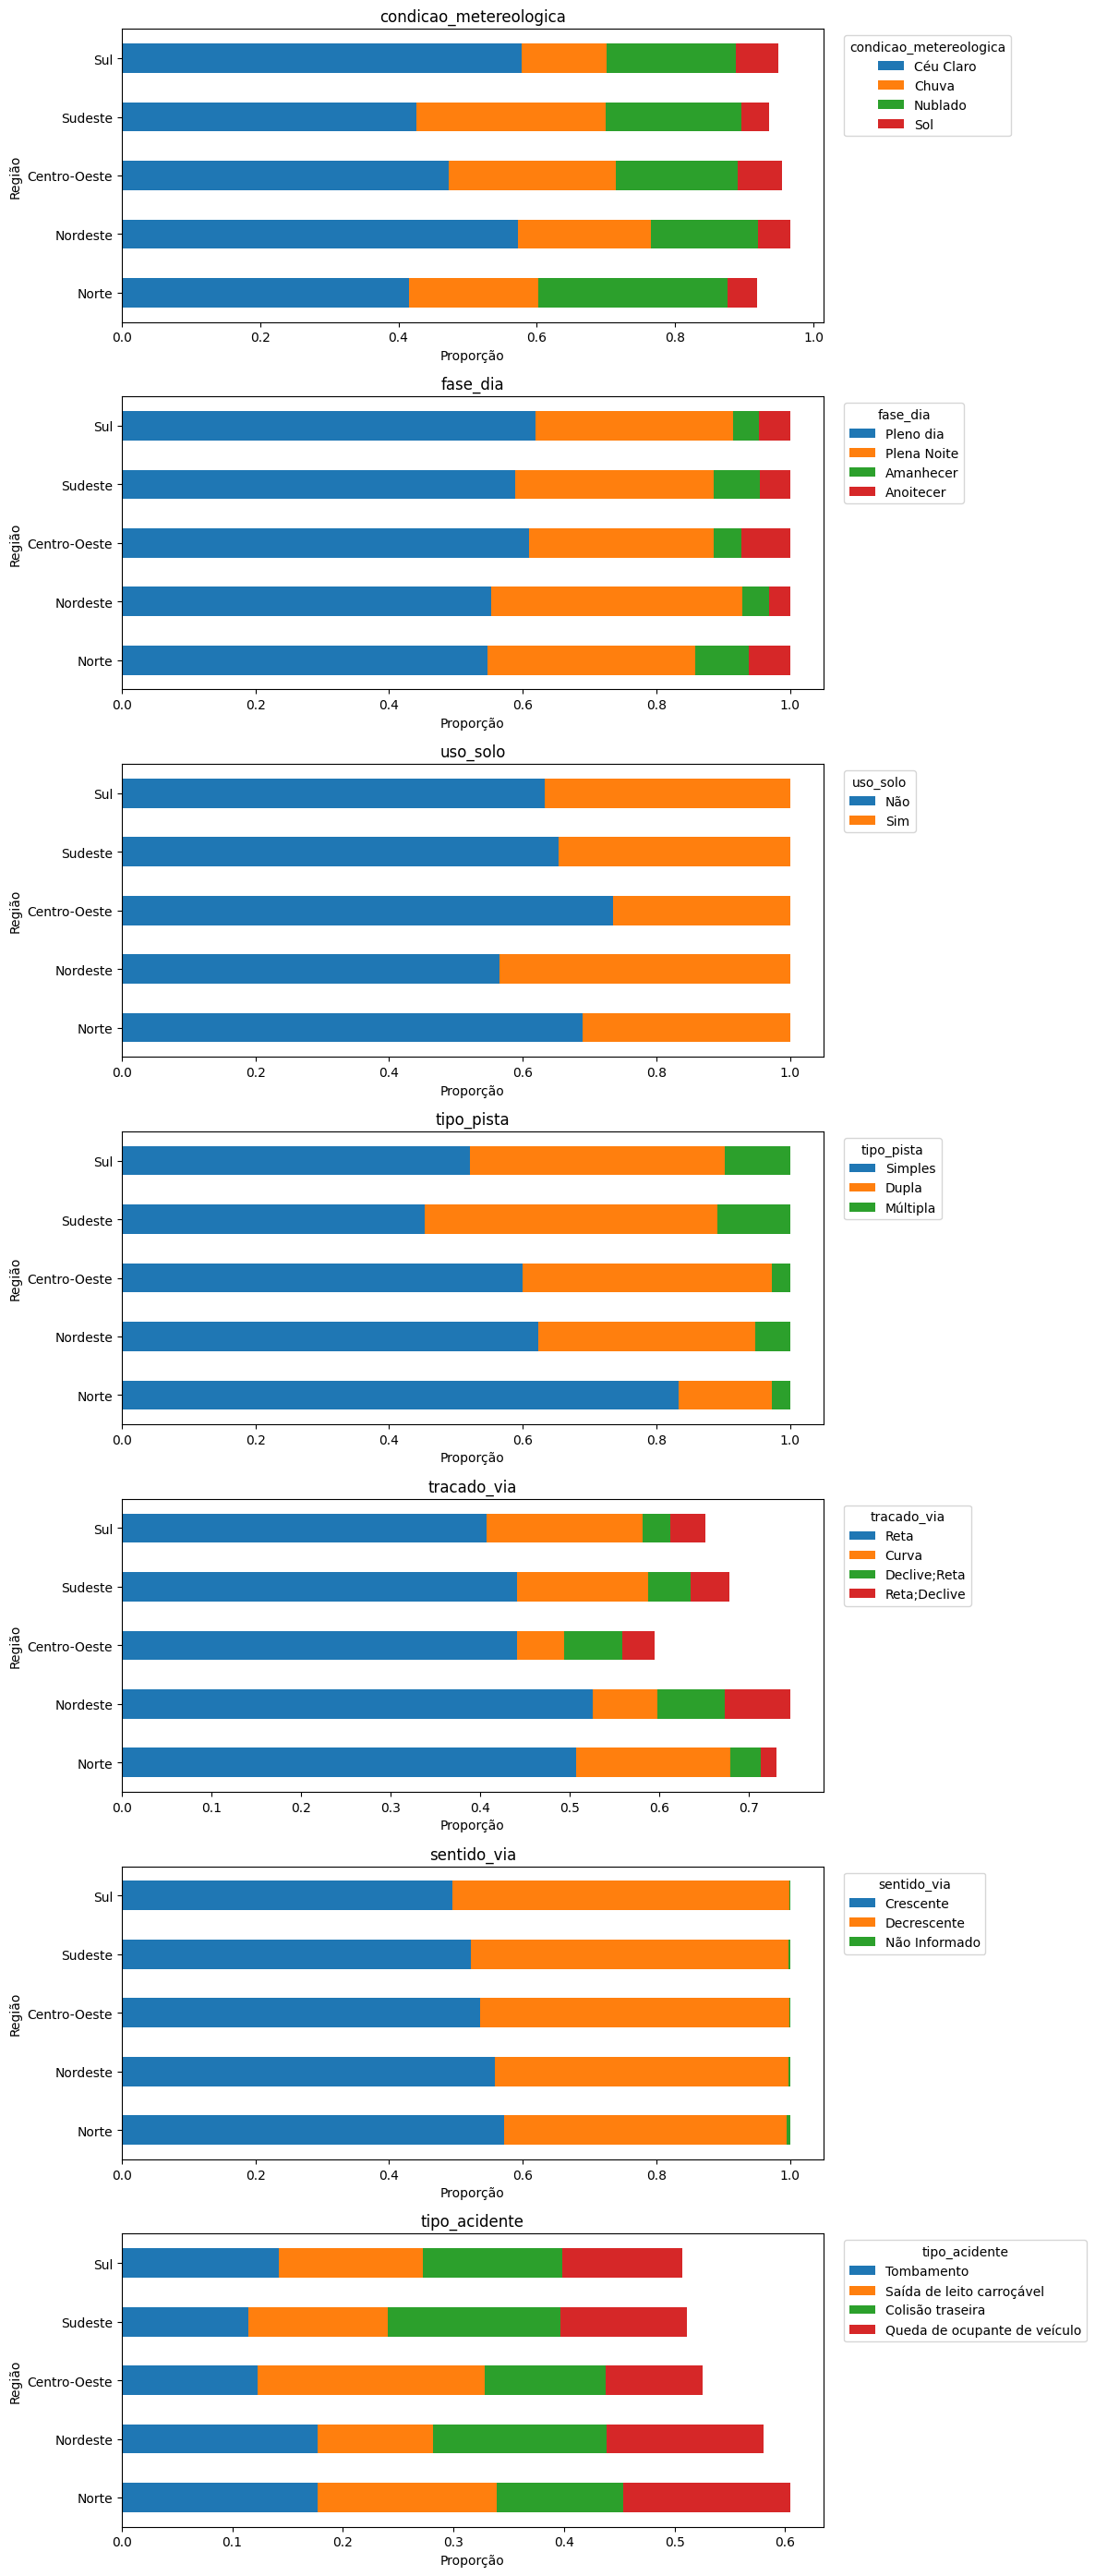

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

map_regiao = {
    "AC":"Norte","AP":"Norte","AM":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",
    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste","PB":"Nordeste","PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",
    "DF":"Centro-Oeste","GO":"Centro-Oeste","MT":"Centro-Oeste","MS":"Centro-Oeste",
    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",
    "PR":"Sul","RS":"Sul","SC":"Sul"
}

dados["regiao"] = dados["uf"].map(map_regiao)

col_names = [
    "condicao_metereologica", "fase_dia", "uso_solo",
    "tipo_pista", "tracado_via", "sentido_via", "tipo_acidente"
]

ordem = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

fig, axes = plt.subplots(len(col_names), 1, figsize=(12, 4 * len(col_names)))

if len(col_names) == 1:
    axes = [axes]

for i, col in enumerate(col_names):
    tab = pd.crosstab(
        dados["regiao"],
        dados[col],
        normalize="index"
    )

    top_cat = dados[col].value_counts().nlargest(4).index
    tab = tab[top_cat]
    tab = tab.reindex(ordem)

    tab.plot(
        kind="barh",
        stacked=True,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Proporção")
    axes[i].set_ylabel("Região")
    axes[i].legend(
        title=col,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.tight_layout()
plt.show()

A figura apresenta a distribuição proporcional das categorias das variáveis por macrorregião do Brasil, ou seja, mostra como os acidentes se distribuem internamente em cada região, independentemente do volume total.

De modo geral, as condições meteorológicas e a fase do dia apresentam padrões semelhantes entre as regiões, com predominância de céu claro e ocorrências durante o período diurno, indicando que esses fatores não diferenciam significativamente o perfil regional dos acidentes.

O uso do solo evidencia que a maior parte dos acidentes ocorre fora de áreas urbanas, reforçando o caráter rodoviário dos dados analisados.

As principais diferenças regionais aparecem na variável tipo de pista. Norte e Centro-Oeste concentram maior proporção de acidentes em pistas simples, enquanto Sudeste e Sul apresentam maior participação de pistas duplas, refletindo diferenças na infraestrutura viária.

Quanto ao tipo de acidente, observa-se que Norte e Nordeste apresentam maior participação de eventos associados à perda de controle ou maior vulnerabilidade, enquanto Sudeste e Sul concentram mais colisões traseiras, padrão típico de regiões com maior fluxo de veículos.

Em síntese, os resultados indicam que o perfil dos acidentes varia entre as regiões e está mais associado às condições estruturais das rodovias e ao padrão de tráfego do que a fatores ambientais.


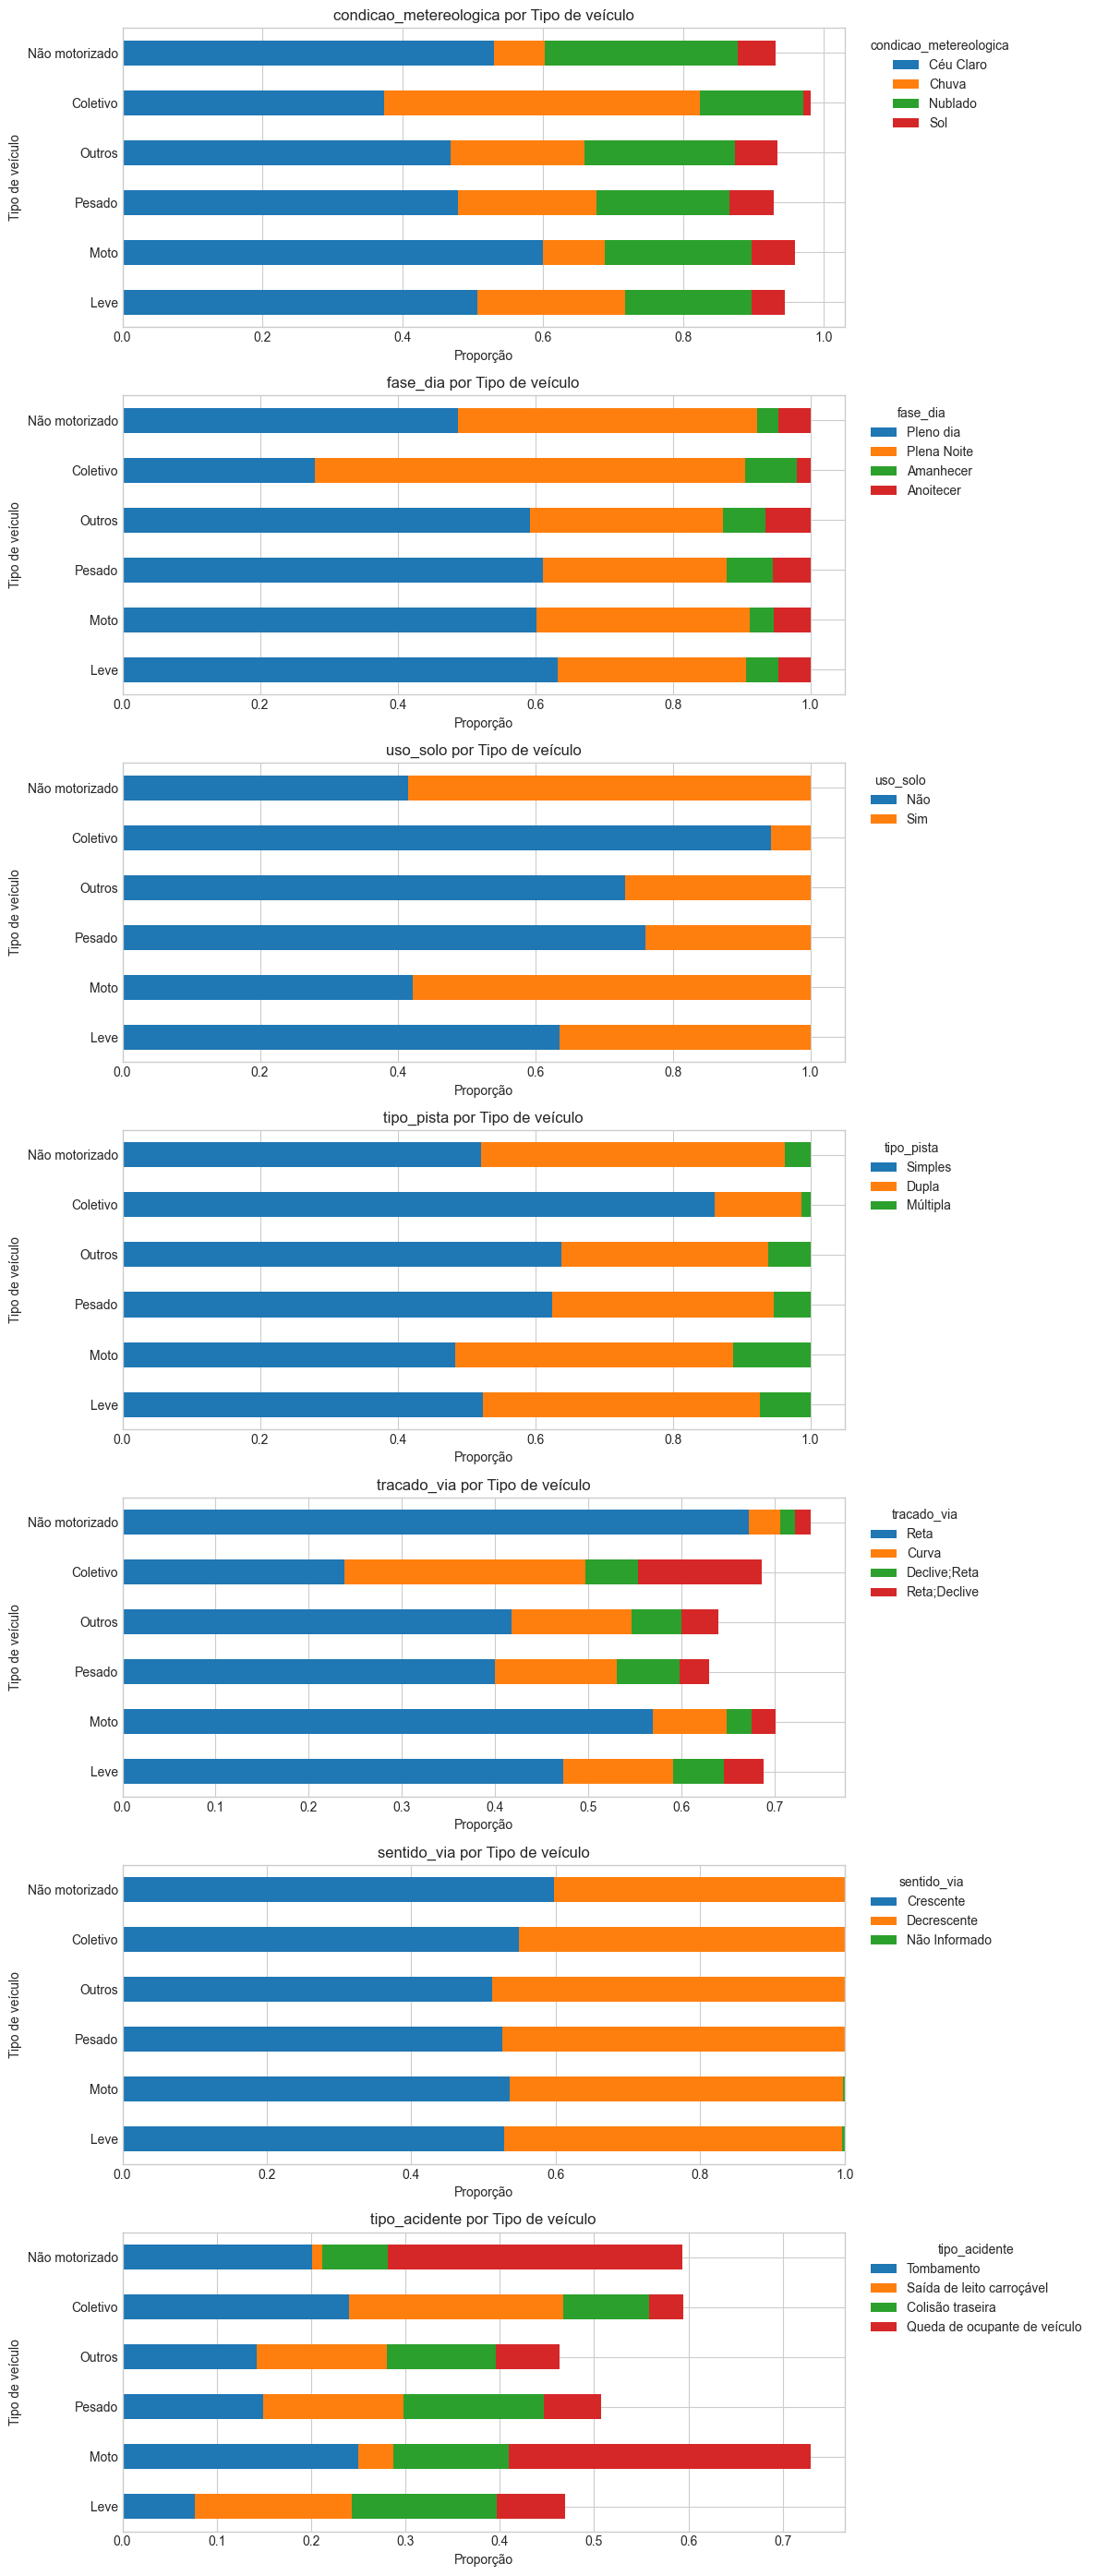

In [135]:
map_veiculo = {
    "Automóvel": "Leve",
    "Caminhonete": "Leve",
    "Camioneta": "Leve",
    "Utilitário": "Leve",

    "Motocicleta": "Moto",
    "Motoneta": "Moto",
    "Ciclomotor": "Moto",

    "Caminhão": "Pesado",
    "Caminhão-trator": "Pesado",
    "Reboque": "Pesado",
    "Semirreboque": "Pesado",

    "Ônibus": "Coletivo",
    "Micro-ônibus": "Coletivo",

    "Bicicleta": "Não motorizado",
    "Pedestre": "Não motorizado"
}

dados["grupo_veiculo"] = dados["tipo_veiculo"].map(map_veiculo).fillna("Outros")

import pandas as pd
import matplotlib.pyplot as plt

col_names = [
    "condicao_metereologica", "fase_dia", "uso_solo",
    "tipo_pista", "tracado_via", "sentido_via", "tipo_acidente"
]

ordem = dados["grupo_veiculo"].value_counts().index

fig, axes = plt.subplots(len(col_names), 1, figsize=(12, 4 * len(col_names)))

if len(col_names) == 1:
    axes = [axes]

for i, col in enumerate(col_names):

    tab = pd.crosstab(
        dados["grupo_veiculo"],
        dados[col],
        normalize="index"
    )

    top_cat = dados[col].value_counts().nlargest(4).index
    tab = tab[top_cat]
    tab = tab.loc[ordem]

    tab.plot(
        kind="barh",
        stacked=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} por Tipo de veículo")
    axes[i].set_xlabel("Proporção")
    axes[i].set_ylabel("Tipo de veículo")

    axes[i].legend(
        title=col,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.tight_layout()
plt.show()

A análise descritiva evidencia padrões consistentes entre as variáveis categóricas e o tipo de veículo.

A condição meteorológica apresenta predominância de céu claro em todos os grupos, com baixa variabilidade entre categorias, sugerindo reduzido poder discriminante. A fase do dia concentra-se nos períodos de pleno dia e plena noite, com destaque para maior ocorrência noturna em veículos coletivos, indicando relevância potencial dessa variável.

No uso do solo, observa-se predominância de áreas não urbanas, exceto para motocicletas, que apresentam distribuição mais equilibrada. Quanto ao tipo de pista, há maior frequência em pistas simples, seguida de pistas duplas, com comportamento semelhante entre os grupos.

O traçado da via é majoritariamente reto, com baixa participação de curvas e declives, enquanto o sentido da via apresenta distribuição equilibrada entre crescente e decrescente, indicando limitada capacidade explicativa.

Por fim, o tipo de acidente demonstra maior heterogeneidade, com padrões específicos por grupo, destacando-se tombamentos em veículos pesados e motocicletas, e quedas de ocupantes em motocicletas.

Em síntese, as variáveis fase do dia, uso do solo e tipo de acidente apresentam maior potencial explicativo, ao passo que condição meteorológica, traçado da via e sentido da via mostram menor capacidade de discriminação.
